## Model Selection Demo:

In [52]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations

In [62]:
# Simulate data
np.random.seed(0)
n = 1000
p = 5
X = np.random.randn(n, p) #after this assume X deterministic
beta = np.array([3, 2, 0, 0, 0])  # Only two variables are nonzero
y = X @ beta + np.random.randn(n) * .5 #y is still random bc of epsilon term

# Add a constant to X for intercept
X = sm.add_constant(X)

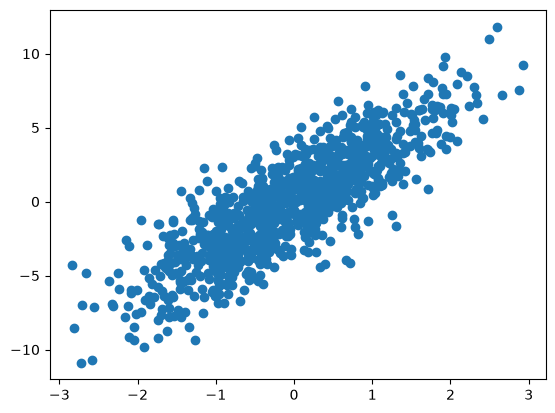

In [63]:
# plot the data
import matplotlib.pyplot as plt
plt.scatter(X[:, 1], y, label='X1 vs y')

In [64]:
# Best subset selection
def best_subset_selection(X, y):
    n, p = X.shape
    models = []
    
    for k in range(1, p + 1):  # Iterate over subset sizes
        for combo in combinations(range(1, p), k):  # Generate combinations of predictors
            combo = (0,) + combo  # Include the intercept
            X_subset = X[:, combo]
            model = sm.OLS(y, X_subset).fit()
            models.append((model, combo))
    
    return models


In [65]:
print(list(combinations(range(1, 5), 2)))

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


In [66]:
combo = (0,) + combinations(range(1, 5), 2).__next__()  # Get the first combination of size 2
combo

(0, 1, 2)

In [67]:
full_model = sm.OLS(y, X).fit()

In [68]:

# Calculate metrics
def calculate_metrics(model, X, y, full_model):
    n = len(y)
    k = model.df_model  # Number of predictors, excluding intercept


    
    # AIC
    aic = model.aic
    
    # BIC
    bic = model.bic
    
    
    # PRESS (Prediction Sum of Squares)
    hat_matrix = X @ np.linalg.inv(X.T @ X) @ X.T #X(XTX)^-1XT
    residuals = model.resid
    press = np.sum((residuals / (1 - np.diag(hat_matrix))) ** 2) #diag pulls out the leverage
    
    # Adjusted R-squared
    r2 = model.rsquared
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    #Mallow's Cp
    sse_k = (np.sum(model.resid**2))
    mse_full = sum((full_model.resid)**2) / (n - p)
    cp =  sse_k / mse_full + 2*(k + 1) - n
    
    return aic, bic, press, adj_r2, cp, int(k) #dont consider intercept as a predictor



In [69]:
# Run best subset selection
models = best_subset_selection(X, y)

In [70]:
# Store results in pd DataFrame
results = []
for model, combo in models:
    aic, bic, press, adj_r2, cp, num_predictors = calculate_metrics(model, X[:, combo], y, full_model)
    results.append({
        'Predictors': combo,
        'n_Predictors': num_predictors,
        'AIC': aic,
        'BIC': bic,
        'PRESS': press,
        'Adjusted R^2': adj_r2,
        'Mallows C_p': cp
    })

# Convert results to pd DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='n_Predictors').reset_index(drop=True)


In [71]:
# Display our results
pd.set_option('display.max_columns', None)  # Show all columns
results_df #0 represents intercept – all models include intercept

,Predictors,n_Predictors,AIC,BIC,PRESS,Adjusted R^2,Mallows C_p
0,"(0, 1)",1,4168.840872,4178.656382,3785.152258,0.707386,14546.869148
1,"(0, 2)",1,5038.813069,5048.628579,9034.712100,0.301575,36102.411605
2,"(0, 3)",1,5398.209642,5408.025152,12939.470547,-0.000469,52146.167492
3,"(0, 4)",1,5397.641492,5407.457002,12933.138971,0.000099,52115.983336
4,"(0, 5)",1,5398.175148,5407.990659,12939.770161,-0.000434,52144.334463
5,"(0, 4, 5)",2,5399.000246,5413.723512,12950.664816,-0.000262,52083.936430
6,"(0, 3, 5)",2,5399.630015,5414.353281,12957.963976,-0.000892,52117.373781
7,"(0, 3, 4)",2,5399.106491,5413.829757,12951.514629,-0.000368,52089.575986
8,"(0, 2, 5)",2,5039.863992,5054.587258,9043.968854,0.301538,36069.219080
9,"(0, 2, 4)",2,5039.363033,5054.086299,9040.554097,0.301888,36050.656577
